In [53]:
import h5py 
import os
from pathlib import Path

import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from sam2.addons import write_h5
from skimage.measure import label, regionprops_table, regionprops

import pandas as pd

In [61]:
root = Path("/Volumes/warm_SD/data/285/00_series/00")

specimen = "285_00_03_50x"

binary_path = root / f"{specimen}.bin2.tif"
image_path = root / f"{specimen}.tif"
mask_path = root / f"{specimen}.mask.tif"
instance_path = root / f"{specimen}.instances.tif"

In [62]:
img = np.array(Image.open(image_path))
bin = np.array(Image.open(binary_path))
mask = np.array(Image.open(mask_path))
# inst = np.array(Image.open(instance_path))

In [63]:
np.unique(bin)

array([0, 1], dtype=uint8)

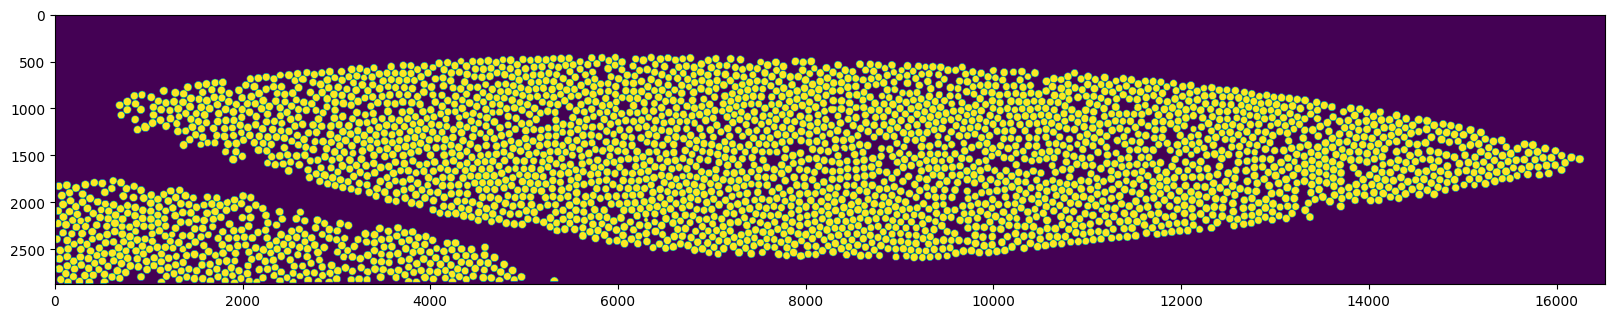

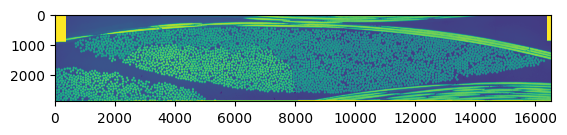

In [64]:
plt.figure(figsize=(20,5))
plt.imshow(bin > 0)
plt.show()

plt.imshow(img)
plt.show()


3457


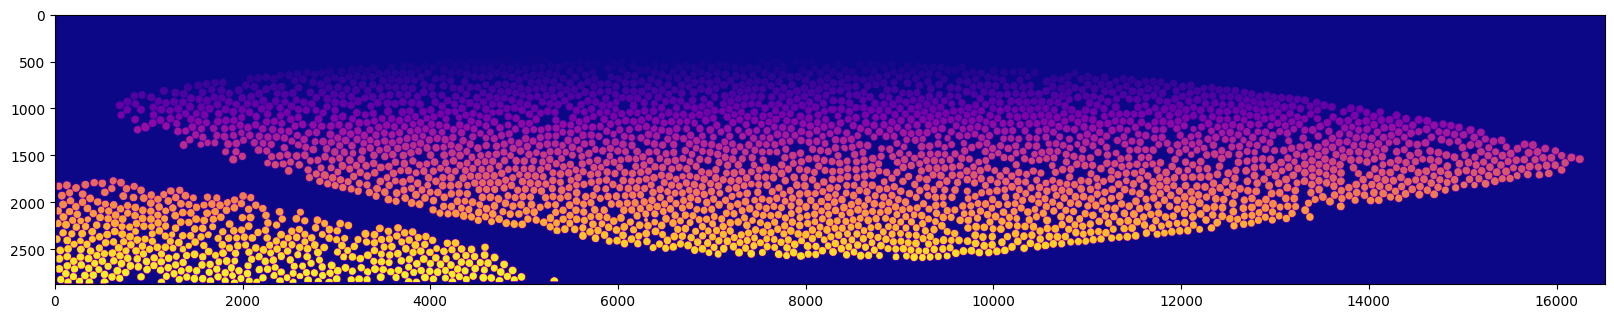

In [65]:
labels = label(bin, connectivity=None)
plt.figure(figsize=(20,5))
plt.imshow(labels,cmap="plasma")
labels =labels.astype(np.int16)
print(len(np.unique(labels)))

61.047294349871244 93.62147737542311
Number of regions: 6
Average equivalent diameter: 80.01 px
Scale based on Average equivalent diameter: 0.087 µm/px
   label   centroid-0    centroid-1  equivalent_diameter  axis_major_length  \
0   8666  1203.731116    961.764962            93.621477          97.872820   
1  30848  1675.496084  15460.100196            88.331262          88.783546   
2   6113  1622.348340  15712.154289            88.028040          89.022650   
3  29064  1526.975892  16156.344287            87.810812          89.679278   
4   2288  1612.401954  15891.747599            87.680217          90.184929   

   axis_minor_length  
0          89.847104  
1          87.910945  
2          87.129496  
3          86.004170  
4          85.301959  


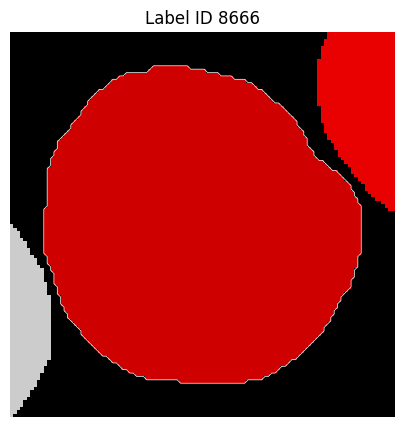

In [66]:
# multiply with mask but keep dtype
labels_masked = (labels *mask ).astype(labels.dtype)

props = regionprops_table(
    labels_masked,
    properties=('label', 'centroid', 'equivalent_diameter', 'axis_major_length', 'axis_minor_length'),
)

diameters = props["equivalent_diameter"]

avg_diameter = np.mean(diameters)
print(np.array(diameters).min(),np.array(diameters).max())

print(f"Number of regions: {len(props)}")
print(f"Average equivalent diameter: {avg_diameter:.2f} px")
print(f"Scale based on Average equivalent diameter: {7.0/avg_diameter:.3f} µm/px")



df_props = pd.DataFrame(props)

df_props = df_props.sort_values(by="equivalent_diameter", ascending=False).reset_index(drop=True)

print(df_props.head())

label_id = df_props["label"].iloc[0]

mask_id = labels_masked == label_id

# Use regionprops to get its bounding box
prop = regionprops(mask_id.astype(np.uint8))[0]
print(prop)

minr, minc, maxr, maxc = prop.bbox

# Crop region (optionally add padding)
pad = 10
minr = max(0, minr - pad)
minc = max(0, minc - pad)
maxr = min(labels.shape[0], maxr + pad)
maxc = min(labels.shape[1], maxc + pad)

# Crop arrays
crop_labels = labels[minr:maxr, minc:maxc]
crop_mask   = mask_id[minr:maxr, minc:maxc]

# Show the cropped label region
plt.figure(figsize=(5,5))
plt.imshow(crop_labels, cmap="nipy_spectral")
plt.contour(crop_mask, colors="white", linewidths=0.5)
plt.title(f"Label ID {label_id}")
plt.axis("off")
plt.show()

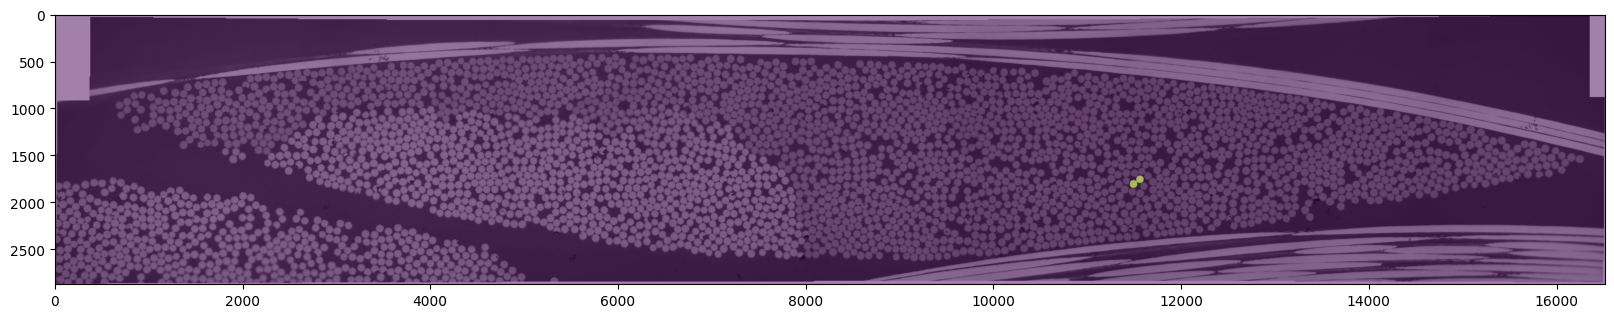

In [52]:
plt.figure(figsize=(20,10))
plt.imshow(img,cmap="gray")
plt.imshow(mask_id.astype(np.uint8),alpha=0.5)

In [92]:
labels = np.array(labels, dtype=np.uint16)
Image.fromarray(labels, mode='I;16').save(instance_path)

In [47]:
plt.figure(figsize=(20, 5))

mask = inst == 0

ys, xs = np.where(mask)


x_min, x_max = xs.min(), xs.max()
y_min, y_max = ys.min(), ys.max()

print(x_min,x_max,y_min,y_max)

plt.imshow(mask, cmap="gray")
plt.title("Label == 102")
plt.axis("off")
plt.show()

NameError: name 'inst' is not defined

<Figure size 2000x500 with 0 Axes>